# Daily Challenge: Building Your First Neural Network on the MNIST Dataset

**Goals**
- Load and preprocess the MNIST dataset
- Build and train a simple fully connected neural network for digit classification
- Evaluate performance using accuracy and a confusion matrix
- Run a basic hyperparameter tuning experiment

## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## 1. Load and Preprocess the MNIST Dataset

- Load MNIST (already split into train/test by Keras)
- Normalize pixel values to [0, 1]
- One-hot encode the labels
- Display a few sample images with their labels

In [2]:
# Load the dataset (Keras provides a ready-made train/test split)
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Raw train images:", x_train.shape, "labels:", y_train.shape)
print("Raw test  images:", x_test.shape, "labels:", y_test.shape)
print("Pixel value range before normalization:", x_train.min(), "-", x_train.max())

Raw train images: (60000, 28, 28) labels: (60000,)
Raw test  images: (10000, 28, 28) labels: (10000,)
Pixel value range before normalization: 0 - 255


In [3]:
# Normalize pixel values from [0, 255] to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# One-hot encode the labels (10 classes: digits 0-9)
y_train_oh = to_categorical(y_train, num_classes=10)
y_test_oh = to_categorical(y_test, num_classes=10)

print("Pixel value range after normalization:", x_train.min(), "-", x_train.max())
print("One-hot label shape:", y_train_oh.shape, y_test_oh.shape)
print("Example: label", y_train[0], "->", y_train_oh[0])

Pixel value range after normalization: 0.0 - 1.0
One-hot label shape: (60000, 10) (10000, 10)
Example: label 5 -> [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


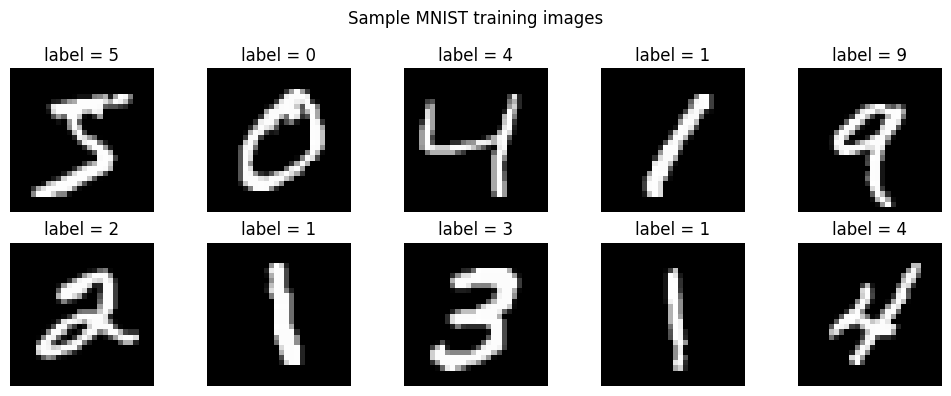

In [4]:
# Display sample images with their corresponding labels
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"label = {y_train[i]}")
    plt.axis("off")
plt.suptitle("Sample MNIST training images")
plt.tight_layout()
plt.show()

## 2. Build a Fully Connected Neural Network

- `Input(28, 28)` then `Flatten` to a 784-vector
- Two hidden `Dense` layers with ReLU activation
- Output `Dense(10)` with Softmax for multi-class classification
- Compile with `adam`, `categorical_crossentropy` loss, `accuracy` metric

In [5]:
def build_model(hidden_units=(128, 64), learning_rate=0.001):
    """Build and compile a fully connected MNIST classifier."""
    model = models.Sequential([
        layers.Input(shape=(28, 28)),   # explicit input layer (recommended by Keras)
        layers.Flatten(),               # 28x28 -> 784
        layers.Dense(hidden_units[0], activation="relu"),
        layers.Dense(hidden_units[1], activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Train the Neural Network

- Fit for 10 epochs
- Use a validation split to track generalization during training
- Plot the loss and accuracy trends

In [6]:
history = model.fit(
    x_train, y_train_oh,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=2,
)

Epoch 1/10
1688/1688 - 2s - 1ms/step - accuracy: 0.9238 - loss: 0.2552 - val_accuracy: 0.9585 - val_loss: 0.1392
Epoch 2/10
1688/1688 - 1s - 630us/step - accuracy: 0.9684 - loss: 0.1033 - val_accuracy: 0.9700 - val_loss: 0.0982
Epoch 3/10
1688/1688 - 1s - 680us/step - accuracy: 0.9771 - loss: 0.0740 - val_accuracy: 0.9752 - val_loss: 0.0829
Epoch 4/10
1688/1688 - 1s - 761us/step - accuracy: 0.9822 - loss: 0.0558 - val_accuracy: 0.9777 - val_loss: 0.0804
Epoch 5/10
1688/1688 - 1s - 644us/step - accuracy: 0.9851 - loss: 0.0457 - val_accuracy: 0.9782 - val_loss: 0.0762
Epoch 6/10
1688/1688 - 1s - 631us/step - accuracy: 0.9887 - loss: 0.0347 - val_accuracy: 0.9745 - val_loss: 0.0975
Epoch 7/10
1688/1688 - 1s - 627us/step - accuracy: 0.9902 - loss: 0.0295 - val_accuracy: 0.9753 - val_loss: 0.1075
Epoch 8/10
1688/1688 - 1s - 639us/step - accuracy: 0.9913 - loss: 0.0261 - val_accuracy: 0.9768 - val_loss: 0.0889
Epoch 9/10
1688/1688 - 1s - 678us/step - accuracy: 0.9934 - loss: 0.0204 - val_acc

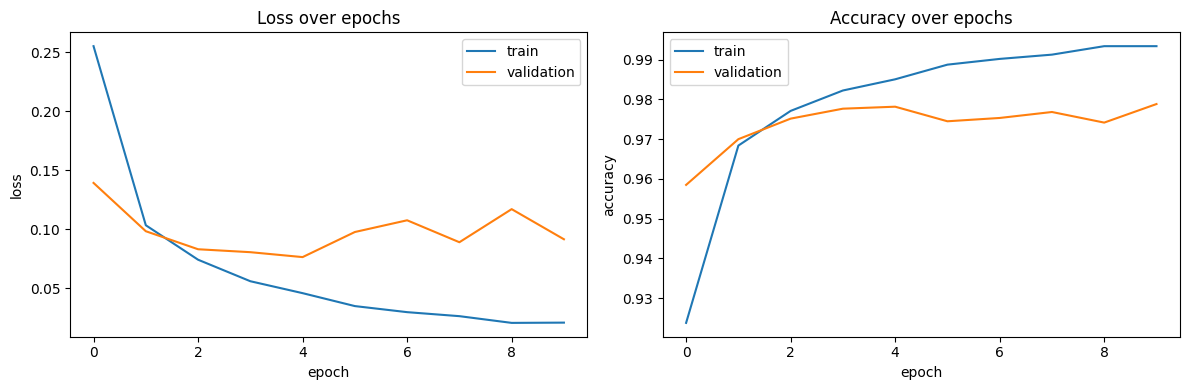

In [7]:
# Plot training/validation loss and accuracy over the epochs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="validation")
axes[0].set_title("Loss over epochs")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="validation")
axes[1].set_title("Accuracy over epochs")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Evaluate the Model's Performance

- Compute accuracy on the test set
- Display a confusion matrix
- Identify which digits the model struggles with the most

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test_oh, verbose=0)
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss:     0.0889
Test accuracy: 0.9776


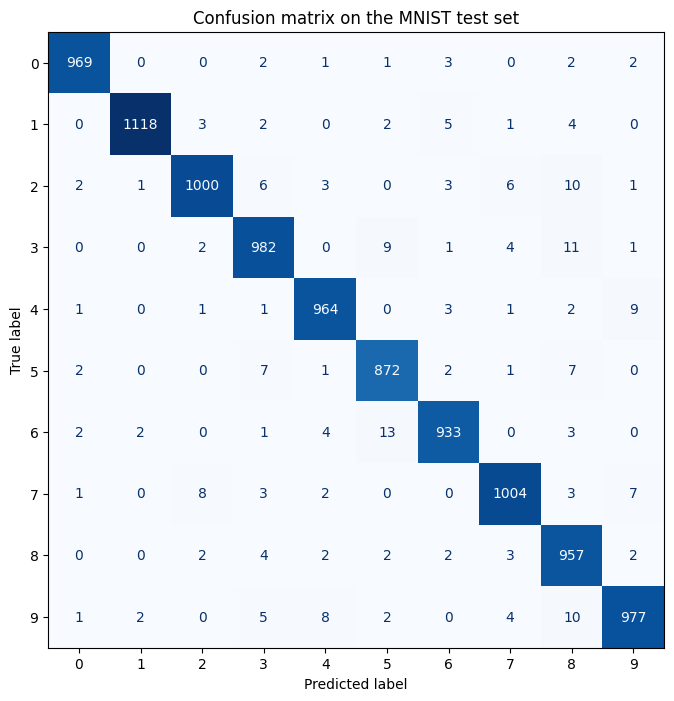

In [9]:
# Predicted class for each test image
y_prob = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# Confusion matrix (rows = true label, cols = predicted label)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10)).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title("Confusion matrix on the MNIST test set")
plt.show()

In [10]:
# Per-digit precision/recall/F1 and the hardest digits to classify
print(classification_report(y_test, y_pred, digits=4))

# Per-class accuracy = correct / total for each true digit
per_class_acc = cm.diagonal() / cm.sum(axis=1)
for digit, acc in enumerate(per_class_acc):
    print(f"digit {digit}: accuracy = {acc:.4f}")

worst = np.argsort(per_class_acc)[:3]
print("\nDigits the model struggles with the most:", worst.tolist())

              precision    recall  f1-score   support

           0     0.9908    0.9888    0.9898       980
           1     0.9955    0.9850    0.9903      1135
           2     0.9843    0.9690    0.9766      1032
           3     0.9694    0.9723    0.9708      1010
           4     0.9787    0.9817    0.9802       982
           5     0.9678    0.9776    0.9727       892
           6     0.9800    0.9739    0.9770       958
           7     0.9805    0.9767    0.9786      1028
           8     0.9485    0.9825    0.9652       974
           9     0.9780    0.9683    0.9731      1009

    accuracy                         0.9776     10000
   macro avg     0.9773    0.9776    0.9774     10000
weighted avg     0.9778    0.9776    0.9776     10000

digit 0: accuracy = 0.9888
digit 1: accuracy = 0.9850
digit 2: accuracy = 0.9690
digit 3: accuracy = 0.9723
digit 4: accuracy = 0.9817
digit 5: accuracy = 0.9776
digit 6: accuracy = 0.9739
digit 7: accuracy = 0.9767
digit 8: accuracy = 0.982

Total misclassified: 224 / 10000


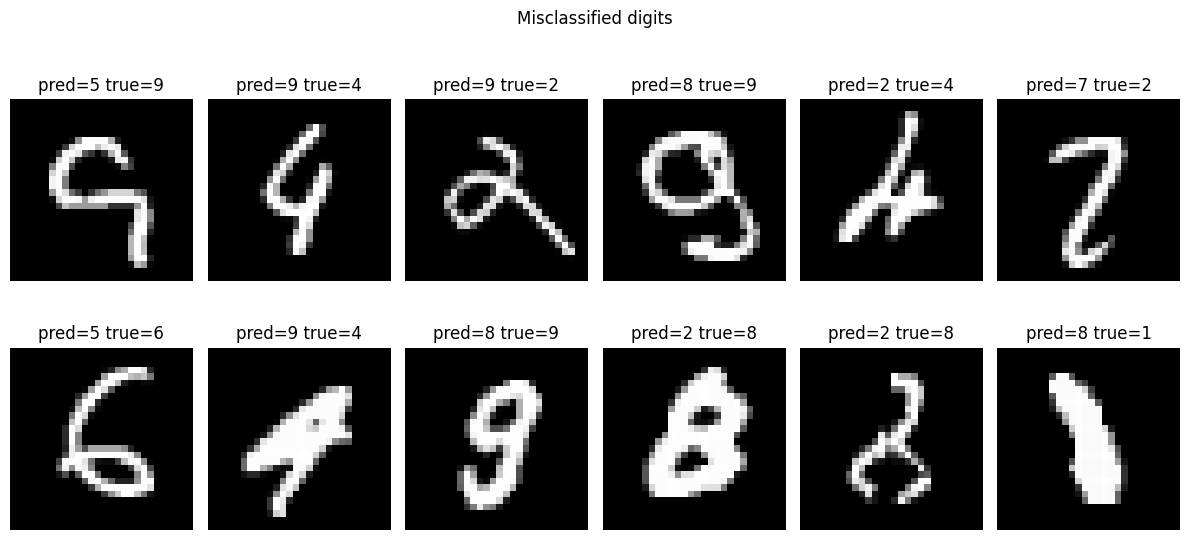

In [11]:
# Visualize a few misclassified examples
mis_idx = np.where(y_pred != y_test)[0]
print(f"Total misclassified: {len(mis_idx)} / {len(y_test)}")

show = mis_idx[:12]
plt.figure(figsize=(12, 6))
for i, k in enumerate(show, 1):
    plt.subplot(2, 6, i)
    plt.imshow(x_test[k], cmap="gray")
    plt.title(f"pred={y_pred[k]} true={y_test[k]}")
    plt.axis("off")
plt.suptitle("Misclassified digits")
plt.tight_layout()
plt.show()

## 5. Bonus: Basic Hyperparameter Tuning

We retrain the same architecture with a few hyperparameter combinations
(hidden-layer sizes, learning rate, batch size) and compare test accuracy.
We use fewer epochs here to keep the search quick.

In [12]:
experiments = [
    {"hidden_units": (128, 64), "learning_rate": 0.001, "batch_size": 32},
    {"hidden_units": (256, 128), "learning_rate": 0.001, "batch_size": 64},
    {"hidden_units": (128, 64), "learning_rate": 0.0005, "batch_size": 128},
]

results = []
for cfg in experiments:
    m = build_model(hidden_units=cfg["hidden_units"], learning_rate=cfg["learning_rate"])
    h = m.fit(
        x_train, y_train_oh,
        epochs=5,
        batch_size=cfg["batch_size"],
        validation_split=0.1,
        verbose=0,
    )
    _, acc = m.evaluate(x_test, y_test_oh, verbose=0)
    results.append({**cfg, "val_acc": h.history["val_accuracy"][-1], "test_acc": acc})
    print(f"{cfg}  ->  test_acc = {acc:.4f}")

best = max(results, key=lambda r: r["test_acc"])
print("\nBest configuration:", best)

{'hidden_units': (128, 64), 'learning_rate': 0.001, 'batch_size': 32}  ->  test_acc = 0.9752
{'hidden_units': (256, 128), 'learning_rate': 0.001, 'batch_size': 64}  ->  test_acc = 0.9775
{'hidden_units': (128, 64), 'learning_rate': 0.0005, 'batch_size': 128}  ->  test_acc = 0.9705

Best configuration: {'hidden_units': (256, 128), 'learning_rate': 0.001, 'batch_size': 64, 'val_acc': 0.9803333282470703, 'test_acc': 0.9775000214576721}


## Conclusion

- A simple fully connected network (Flatten -> Dense(128) -> Dense(64) -> Dense(10, softmax))
  reaches roughly **97-98% test accuracy** on MNIST.
- The confusion matrix shows most errors come from visually similar digits
  (e.g. 4/9, 3/5, 7/9).
- Hyperparameter tuning (wider layers, learning rate, batch size) gives small
  but measurable gains. Convolutional networks would push accuracy higher,
  since they exploit the spatial structure that flattening discards.